# MODELADO IRAIA

Cosas que hacer:
- primero train test y luego escalar y dummies
- ANalizar los coeficientes y odds ratios
- Aplico PCA???

In [1]:
# Cargar librerias
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
np.random.seed(0)

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import os

In [2]:
# Cargar datos
df = pd.read_csv("df_limpio_con_clusters.csv")
df_clustering= pd.read_csv("df_modelado_clustering.csv", sep=",", low_memory=False)
df_tiempo = pd.read_csv("datos_meteorologicos_2023.csv")


In [3]:
#Tamaño
print(f"Df_Limpio: {df.shape}")
print(f"Df_Tiempo: {df_tiempo.shape}")

Df_Limpio: (51707, 47)
Df_Tiempo: (3285, 22)


In [4]:
#Tipo de variables
print(df.dtypes)
print(df_tiempo.dtypes)

booked_at                          object
checkin_time                       object
lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                        

In [5]:
#Visualizar las primeras 10 filas:
print(f"Df_limpio: {df.head(10)}")
print(f"Df_tiempo: {df_tiempo.head(10)}")


Df_limpio:              booked_at         checkin_time  lead_time  lenght_of_stay  \
0  2022-11-26 16:10:00  2023-01-01 12:00:00         36               1   
1  2022-12-21 17:27:00  2023-01-01 13:09:00         11               9   
2  2022-09-21 19:46:00  2023-01-01 15:00:00        102               6   
3  2022-09-24 12:09:00  2023-01-01 15:00:00         99               1   
4  2022-10-18 07:12:00  2023-01-01 15:00:00         75               1   
5  2022-11-25 17:50:00  2023-01-01 15:00:00         37               1   
6  2022-11-26 04:10:00  2023-01-01 15:00:00         36               2   
7  2022-12-02 20:02:00  2023-01-01 15:00:00         30               1   
8  2022-12-04 23:18:00  2023-01-01 15:00:00         28               2   
9  2022-12-11 12:51:00  2023-01-01 15:00:00         21               7   

  checkin_month checkin_day  adult_count  child_count           origin  \
0       January      Sunday            1            0  channel_manager   
1       January      Sunda

Quedarnos con las variables del df que no tiene relacion con cancelaciones.

In [6]:
columnas_sin_inf_cancelaciones = [
    'checkin_time','lead_time','lenght_of_stay','checkin_month','checkin_day','adult_count','child_count',
    'origin','requested_category','asset','asset_type','business_segment','rate_type',
    'returning_inhabitant','recurrence','libere_community','reservation_net_value',
    'zona_roja_mes','Estacion_Estancia',
    'Estacion_Reserva','estancia_en_festivo','estancia_en_finde','City', 'mes_checkin_numerico',
    'reservation_checkin_month_diff', 'Reserva_Dia_Semana', 'status'
]


df_sin_inf_cancell = df[columnas_sin_inf_cancelaciones]
print(df_sin_inf_cancell)

              checkin_time  lead_time  lenght_of_stay checkin_month  \
0      2023-01-01 12:00:00         36               1       January   
1      2023-01-01 13:09:00         11               9       January   
2      2023-01-01 15:00:00        102               6       January   
3      2023-01-01 15:00:00         99               1       January   
4      2023-01-01 15:00:00         75               1       January   
...                    ...        ...             ...           ...   
51702  2023-12-31 15:00:00         79               1      December   
51703  2023-12-31 15:00:00         79               1      December   
51704  2023-12-31 15:00:00         75               1      December   
51705  2023-12-31 15:00:00         75               1      December   
51706  2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday  

Juntar ambos df-s por (Fecha, Hora, Ciudad)

In [7]:
# Cambiar nombre a la ciudad Donosti (Salen diferente)
df_sin_inf_cancell['City'] = df_sin_inf_cancell['City'].replace({'Donostia': 'Donosti'})

In [8]:
# 1. Crear FECHA desde checkin_time en df reservas
df_sin_inf_cancell['checkin_time'] = pd.to_datetime(df_sin_inf_cancell['checkin_time'])
df_sin_inf_cancell['fecha'] = df_sin_inf_cancell['checkin_time'].dt.date

# 2. Convertir FECHA en df_tiempo (es diaria)
df_tiempo['fecha'] = pd.to_datetime(df_tiempo['fecha']).dt.date


# 3. Merge SOLO por ciudad + fecha
df_junto = df_sin_inf_cancell.merge(
    df_tiempo,
    left_on=['City', 'fecha'],
    right_on=['ciudad', 'fecha'],
    how='left'
)
print(df_junto)

             checkin_time  lead_time  lenght_of_stay checkin_month  \
0     2023-01-01 12:00:00         36               1       January   
1     2023-01-01 13:09:00         11               9       January   
2     2023-01-01 15:00:00        102               6       January   
3     2023-01-01 15:00:00         99               1       January   
4     2023-01-01 15:00:00         75               1       January   
...                   ...        ...             ...           ...   
51702 2023-12-31 15:00:00         79               1      December   
51703 2023-12-31 15:00:00         79               1      December   
51704 2023-12-31 15:00:00         75               1      December   
51705 2023-12-31 15:00:00         75               1      December   
51706 2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday            1 

 Transformación Variables:
 - Eliminar variable "checkin_time" (Necesaria para el merge).
 - Tranfromar variable target "status" a tipo booleana

In [9]:
#Eliminar "checkin_time"
df_junto = df_junto.drop(columns="checkin_time")

#Tranformar Variable "status"
df_junto["status_bool"] = df_junto["status"].map(
    {"checked_out": False,
     "cancelled": True}
)
df_junto["status_bool"]

0        False
1        False
2        False
3        False
4        False
         ...  
51702    False
51703    False
51704    False
51705    False
51706     True
Name: status_bool, Length: 51707, dtype: bool

In [10]:
# Reemplazar la "," po el "." en la variables numericas sobre el tiempo:

# Primero asegurarnos de que las columnas de temperatura sean string
cols_temp = ['tmax', 'tmin', 'tmed', 'hrMedia', 'hrMax', 'hrMin', 'prec', 'dir', 'velmedia', 'racha']  

for col in cols_temp:
    # Convertir category a str
    df_junto[col] = df_junto[col].astype(str)
    # Reemplazar coma por punto
    df_junto[col] = df_junto[col].str.replace(',', '.', regex=False)
    # Convertir a float
    df_junto[col] = df_junto[col].astype(float)

# Comprobar
print(df_junto['tmax'].head(2))


0    21.4
1    21.4
Name: tmax, dtype: float64


In [11]:
#COnvertir al tipo correspodinete, sobre todo las varibales en relacion al tiempo. (Las otras ya estan)
# Bucle para convertir tipos correctamente
for col in df_junto.columns:
    # Si es object
    if df_junto[col].dtype == 'object':
        unique_vals = df_junto[col].dropna().astype(str).unique()  # asegurar que sean strings
        
        # Solo 0/1 → booleano
        if set(unique_vals).issubset({'0', '1', 0, 1}):
            df_junto[col] = df_junto[col].astype(bool)
        
        else:
            # Intentar convertir a float
            try:
                df_junto[col] = pd.to_numeric(df_junto[col], errors='raise')
            except:
                # Si no se puede → category
                df_junto[col] = df_junto[col].astype('category')
                
    # Si ya es booleano → opcional convertir a int
    elif df_junto[col].dtype == 'bool':
        df_junto[col] = df_junto[col].astype(int)


# Comprobar tipos finales
print("tmax:", df_junto["tmax"].dtypes)        # Debe salir float64
print("status_bool:", df_junto["status_bool"].dtypes)  # Debe seguir siendo int64


tmax: float64
status_bool: int64


### Seleccion Variables para los Modelos
1. Numericas: Se analizara su correlacion
2. Booleanas: 
3. Categoricas:

#### NUMERICAS

In [12]:
# 1. NUMERICAS:
# Seleccionar todas las columnas numéricas (int + float)

# Asegurarse de que status_bool es numérico
df_junto['status_bool'] = df_junto['status_bool'].astype(int)
# Extraer nombres de columnas numéricas
variables_numericas = df_junto.select_dtypes(include=['number']).columns.tolist()


# Verificar que 'status_bool' esté incluido
if 'status_bool' not in variables_numericas:
    variables_numericas.append('status_bool')

# Calcular correlación con status_bool
corr_df = df_junto[variables_numericas].corr()
corr_num = corr_df['status_bool'].drop('status_bool').sort_values(ascending=False)

print(corr_num.head(5))



lead_time                         0.215193
reservation_checkin_month_diff    0.210555
zona_roja_mes                     0.164497
lenght_of_stay                    0.132539
adult_count                       0.099740
Name: status_bool, dtype: float64


Total de NaN en variables meteorológicas después de imputación:
tmed    0
tmin    0
tmax    0
prec    0
dtype: int64
Variables numéricas seleccionadas (|corr| >= 0.05 + variables climáticas):
['lead_time', 'reservation_checkin_month_diff', 'zona_roja_mes', 'lenght_of_stay', 'adult_count', 'reservation_net_value', 'estancia_en_finde', 'tmed', 'tmin', 'tmax', 'prec']
Matriz de correlación entre variables seleccionadas:
                                lead_time  reservation_checkin_month_diff  \
lead_time                        1.000000                        0.975990   
reservation_checkin_month_diff   0.975990                        1.000000   
zona_roja_mes                    0.560852                        0.596894   
lenght_of_stay                   0.097910                        0.096510   
adult_count                      0.217532                        0.215002   
reservation_net_value            0.177165                        0.175387   
estancia_en_finde                0.09869

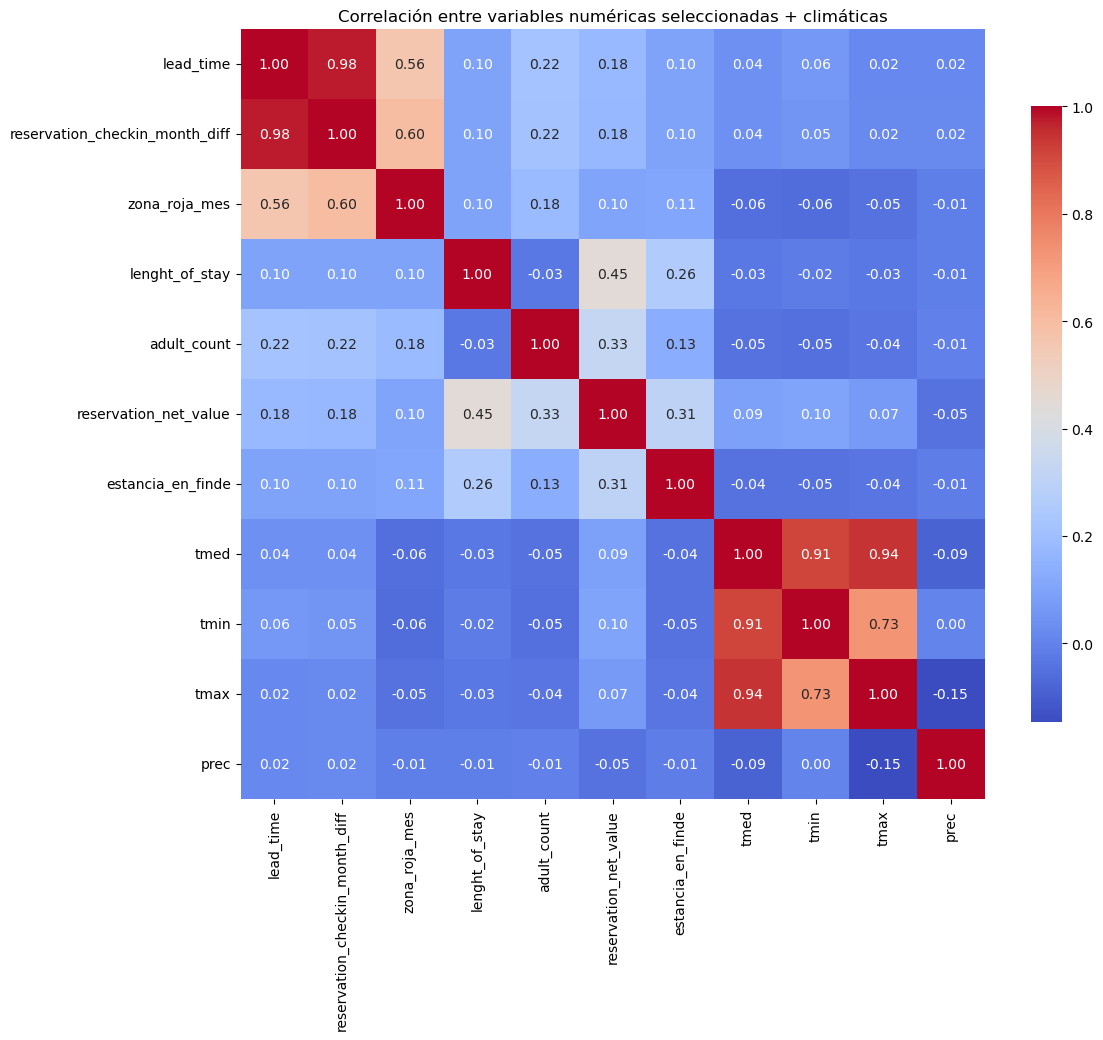

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Umbral de correlación con el target
umbral = 0.05

# Variables numéricas con |corr| >= 0.05
vars_numericas_filtradas = corr_num[corr_num.abs() >= umbral].index.tolist()

# Agregar explícitamente variables meteorológicas aunque no superen el umbral
vars_adicionales = ["tmed", "tmin", "tmax", "prec"]

# -----------------------------
# Imputar valores faltantes en variables meteorológicas
# Explicación:
# - interpolate(): rellena NaN usando interpolación lineal
# - ffill(): rellena NaN restantes hacia adelante
# - bfill(): rellena NaN restantes hacia atrás
df_junto[vars_adicionales] = df_junto[vars_adicionales].interpolate(method='linear')
df_junto[vars_adicionales] = df_junto[vars_adicionales].fillna(method='ffill')
df_junto[vars_adicionales] = df_junto[vars_adicionales].fillna(method='bfill')

# Verificar que no queden NaN en las variables meteorológicas
print("Total de NaN en variables meteorológicas después de imputación:")
print(df_junto[vars_adicionales].isna().sum())

# -----------------------------
# Combinar todas las variables para modelado
for var in vars_adicionales:
    if var not in vars_numericas_filtradas:
        vars_numericas_filtradas.append(var)

print("Variables numéricas seleccionadas (|corr| >= 0.05 + variables climáticas):")
print(vars_numericas_filtradas)

# -----------------------------
# Revisar multicolinealidad entre las variables seleccionadas
corr_variables = df_junto[vars_numericas_filtradas].corr()

print("Matriz de correlación entre variables seleccionadas:")
print(corr_variables)

# Heatmap de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_variables, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'shrink': 0.8})
plt.title("Correlación entre variables numéricas seleccionadas + climáticas")
plt.show()

# -----------------------------
# Observaciones sobre la decisión:
# - Variables con mayor correlación con el target:
#   lead_time, reservation_checkin_month_diff, zona_roja_mes, lenght_of_stay
# - Variables con señal débil pero incluidas (|corr| ~ 0.05-0.08):
#   adult_count, reservation_net_value, estancia_en_finde
# - Se incluyen también variables meteorológicas:
#   tmed, tmin, tmax, prec
# - Ninguna variable presenta alta correlación entre sí (>0.7)
# - Decisión final: usar todas las variables seleccionadas con |corr| >= 0.05
#   y las variables climáticas para modelar cancelaciones
# -----------------------------


#### BINARIAS

In [14]:
# 2.  BINARIAS

# 2.1 Detectar columnas binarias (0/1 o True/False)
binarias_vars = []

for columna in df_junto.columns:
    valores_unicos = df_junto[columna].dropna().unique()
    valores_set = set(valores_unicos)
    
    if valores_set.issubset({0, 1}) or valores_set.issubset({True, False}):
        # Excluir el target
        if columna != 'status_bool':
            binarias_vars.append(columna)

print("Variables binarias detectadas:")
print(binarias_vars)

Variables binarias detectadas:
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


In [15]:
# 2.2 Revisar impacto sobre el target
target_col = 'status_bool'

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    print(f'\nColumna: {columna}')
    print(medias)


Columna: zona_roja_mes
zona_roja_mes
0    0.191143
1    0.352428
Name: status_bool, dtype: float64

Columna: estancia_en_festivo
estancia_en_festivo
0    0.229083
1    0.254162
Name: status_bool, dtype: float64

Columna: estancia_en_finde
estancia_en_finde
0    0.198288
1    0.267638
Name: status_bool, dtype: float64


In [16]:
# 2.3 Filtrar variables binarias relevantes
bin_vars_relevantes = []

umbral_diferencia = 0.02  # 2%

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    diferencia = abs(medias.iloc[1] - medias.iloc[0])
    
    if diferencia > umbral_diferencia:
        bin_vars_relevantes.append(columna)

print("\nVariables binarias relevantes (diferencia > 0.02):")
print(bin_vars_relevantes)


# -----------------------------
# Justificación:
# Consideramos relevantes aquellas variables binarias donde la diferencia 
# en la media del target entre los dos grupos supera el 2%. Diferencias pequeñas
# pueden aportar información combinada con otras variables, pero se priorizan
# aquellas con un impacto más claro sobre la cancelación.
# -----------------------------



Variables binarias relevantes (diferencia > 0.02):
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


#### CATEGORICAS

In [17]:
# 3.  CATEGÓRICAS 

# 3.1 Detectar columnas categóricas
cat_vars = []

for columna in df_junto.columns:
    if df_junto[columna].dtype.name in ['object', 'category']:
        # Excluir la columna target
        if columna != 'status_bool':
            cat_vars.append(columna)

print("Variables categóricas detectadas:")
print(cat_vars)

Variables categóricas detectadas:
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'asset_type', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Estancia', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


In [18]:
# 3.2 Analizar impacto de variables categóricas sobre el target

target_col = 'status_bool'

for columna in cat_vars:
    # Calcular la media del target por cada categoría
    medias = df_junto.groupby(columna)[target_col].mean().sort_values(ascending=False)
    
    #print(f'\nVariable categórica: {columna}')
    #display(medias.head(10))  # Mostrar las 10 categorías con mayor media

In [19]:
# 3.3 Selección de variables categóricas relevantes

cat_vars_significativas = []

umbral_cat = 0.03  # 3%

for col in cat_vars:
    # Calcular la media del target por cada categoría
    medias_target = df_junto.groupby(col)[target_col].mean()
    
    # Diferencia máxima entre las categorías
    diferencia_max = medias_target.max() - medias_target.min()
    
    # Filtrar si supera el umbral
    if diferencia_max > umbral_cat:
        cat_vars_significativas.append(col)

print("\nVariables categóricas consideradas relevantes (diferencia > 0.03):")
print(cat_vars_significativas)

# Justificación:
# Se consideran relevantes aquellas variables categóricas donde la diferencia
# entre la categoría con mayor y menor media del target ('status_bool')
# supera el 3%. Esto refleja un impacto más claro sobre la probabilidad
# de cancelación, mientras que diferencias menores podrían aportar menos información.



Variables categóricas consideradas relevantes (diferencia > 0.03):
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


### Crear DataFrame Final para Modelado 

In [20]:
# CREAR DATAFRAME FINAL PARA MODELADO

# Unir todas las variables seleccionadas con el target
df_modelado_final = df_junto[
    vars_numericas_filtradas +       # Variables numéricas seleccionadas
    bin_vars_relevantes +            # Variables binarias relevantes
    cat_vars_significativas +        # Variables categóricas relevantes
    [target_col]                     # Target
]

# Verificar dimensiones
print(f"Dimensiones: {df_modelado_final.shape}")


Dimensiones: (51707, 39)


In [21]:
# Variables meteorológicas
vars_meteorologicas = ["tmed", "tmin", "tmax", "prec"]

# Comprobar NaN en df_modelado_final
print("Valores faltantes en variables meteorológicas de df_modelado_final:")
print(df_modelado_final[vars_meteorologicas].isna().sum())

# Total de NaN en todas las variables meteorológicas
print("\nTotal de NaN en todas las variables meteorológicas:", 
      df_modelado_final[vars_meteorologicas].isna().sum().sum())


Valores faltantes en variables meteorológicas de df_modelado_final:
tmed    0
tmin    0
tmax    0
prec    0
dtype: int64

Total de NaN en todas las variables meteorológicas: 0


In [22]:
#Eliminar columnas de tipo fecha ya que no aportaran ningun tipo de informacion para el modelo 
df_modelado_final = df_modelado_final.drop(columns=["fecha", "horatmin", "horatmax", "horaracha", "horaHrMax", "horaHrMin"])

### Formatear el Data Frame (Numericas = Escalar, Categoricas = Dummies)

#### Escalar Variables Numericas

In [23]:
# Función para escalar variables numéricas con MinMaxScaler 
def escalar_numericas(df, columnas_numericas=None):
     """ Escala únicamente las columnas numéricas de un DataFrame usando MinMaxScaler. 
     Parámetros ---------- df : pd.DataFrame DataFrame original. columnas_numericas : 
     list (opcional) Lista de columnas numéricas. Si no se pasa, se detectan automáticamente. Retorna ------- pd.DataFrame DataFrame con columnas numéricas escaladas entre 0 y 1. """ 
     df_copy = df.copy() # Detectar columnas numéricas si no se pasan 
     if columnas_numericas is None: 
        columnas_numericas = df_copy.select_dtypes(include=['int64', 'float64']).columns.tolist() 
        scaler = MinMaxScaler() # Escalar solo las numéricas 
        df_copy[columnas_numericas] = scaler.fit_transform(df_copy[columnas_numericas]) 
        return df_copy 
# Aplicar la función al DataFrame 
df_modelado_final = escalar_numericas(df_modelado_final) 
     # Revisar resultado 
print("Primeras filas del DataFrame con variables numéricas escaladas:") 
print(df_modelado_final.head())

Primeras filas del DataFrame con variables numéricas escaladas:
   lead_time  reservation_checkin_month_diff  zona_roja_mes  lenght_of_stay  \
0   0.047461                        0.100000            0.0        0.012658   
1   0.019868                        0.066667            0.0        0.113924   
2   0.120309                        0.166667            0.0        0.075949   
3   0.116998                        0.166667            1.0        0.012658   
4   0.090508                        0.133333            1.0        0.012658   

   adult_count  reservation_net_value  estancia_en_finde      tmed      tmin  \
0          0.1               0.015921                1.0  0.480769  0.554348   
1          0.1               0.117788                1.0  0.480769  0.554348   
2          0.2               0.755703                1.0  0.480769  0.554348   
3          0.2               0.186383                1.0  0.480769  0.554348   
4          0.4               0.077025                1.0  0.4

#### Convertir Categoricas a dummies

In [24]:
def convertir_a_dummies(df, columnas_categoricas=None, drop_first=True):
    """
    Convierte columnas categóricas en variables dummies (one-hot encoding).

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_categoricas : list (opcional)
        Lista de columnas categóricas. Si no se pasa, se detectan automáticamente.
    drop_first : bool
        Si True, elimina la primera categoría (evita colinealidad).

    Retorna
    -------
    pd.DataFrame
        DataFrame con las columnas categóricas convertidas en dummies.
    """

    df_copy = df.copy()

    # Detectar categóricas si no se pasan
    if columnas_categoricas is None:
        columnas_categoricas = df_copy.select_dtypes(include=['object', 'category']).columns.tolist()

    # Convertir a dummies
    df_dummies = pd.get_dummies(df_copy, columns=columnas_categoricas, drop_first=drop_first)

    return df_dummies

# Aplicar la función al DataFrame escalado
# =========================================================
df_modelado_final = convertir_a_dummies(df_modelado_final) # Revisar resultado 
print("DataFrame final con variables categóricas convertidas a dummies:") 
print(df_modelado_final.head()) 
print(f"Dimensiones finales: {df_modelado_final.shape}")



DataFrame final con variables categóricas convertidas a dummies:
   lead_time  reservation_checkin_month_diff  zona_roja_mes  lenght_of_stay  \
0   0.047461                        0.100000            0.0        0.012658   
1   0.019868                        0.066667            0.0        0.113924   
2   0.120309                        0.166667            0.0        0.075949   
3   0.116998                        0.166667            1.0        0.012658   
4   0.090508                        0.133333            1.0        0.012658   

   adult_count  reservation_net_value  estancia_en_finde      tmed      tmin  \
0          0.1               0.015921                1.0  0.480769  0.554348   
1          0.1               0.117788                1.0  0.480769  0.554348   
2          0.2               0.755703                1.0  0.480769  0.554348   
3          0.2               0.186383                1.0  0.480769  0.554348   
4          0.4               0.077025                1.0  0.

#### Eliminar filas duplicadas:

In [25]:
# Revisar duplicados considerando todas las columnas excepto el target 
duplicados = df_modelado_final.drop(columns=['status_bool']).duplicated(keep=False) 
print("Filas duplicadas:", duplicados.sum()) # Eliminar duplicados exactos en las features 
df_modelado_final = df_modelado_final.drop_duplicates() 
print("Nuevo tamaño del DataFrame:", df_modelado_final.shape)

Filas duplicadas: 4925
Nuevo tamaño del DataFrame: (48817, 122)


In [26]:
# 1. Separar el df y target 
X = df_modelado_final.drop(columns=['status_bool', 'status_checked_out']) # todas las variables excepto el target 
y = df_modelado_final['status_bool'] # target

### Train / Test

In [27]:
# 2. División en train y test 
# # test_size = 0.2 → 20% de los datos para test 
# # stratify = y → asegura que la proporción de clases en train/test sea la misma que en el dataset original 
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y ) 

# 3. Comprobar tamaños 
print(f"Tamaño X_train: {X_train.shape}") 
print(f"Tamaño X_test: {X_test.shape}") 
print(f"Tamaño y_train: {y_train.shape}") 
print(f"Tamaño y_test: {y_test.shape}")

Tamaño X_train: (39053, 120)
Tamaño X_test: (9764, 120)
Tamaño y_train: (39053,)
Tamaño y_test: (9764,)


In [28]:
# 4. Comprobar valores faltantes (NaN) en train y test

# -- X_train
print("\n=== Valores faltantes en X_train ===")
print(X_train.isna().sum())                     # NaN por columna
print(f"Total de NaN en X_train: {X_train.isna().sum().sum()}")   # Total NaN
print("\nPorcentaje de NaN por columna en X_train:")
print((X_train.isna().sum() / len(X_train) * 100).sort_values(ascending=False))

# -- X_test
print("\n=== Valores faltantes en X_test ===")
print(X_test.isna().sum())                     # NaN por columna
print(f"Total de NaN en X_test: {X_test.isna().sum().sum()}")     # Total NaN
print("\nPorcentaje de NaN por columna en X_test:")
print((X_test.isna().sum() / len(X_test) * 100).sort_values(ascending=False))


=== Valores faltantes en X_train ===
lead_time                         0
reservation_checkin_month_diff    0
zona_roja_mes                     0
lenght_of_stay                    0
adult_count                       0
                                 ..
ciudad_Vitoria                    0
codigo_ccaa_ES-MD                 0
codigo_ccaa_ES-NC                 0
codigo_ccaa_ES-PV                 0
codigo_ccaa_ES-VC                 0
Length: 120, dtype: int64
Total de NaN en X_train: 0

Porcentaje de NaN por columna en X_train:
lead_time                         0.0
reservation_checkin_month_diff    0.0
zona_roja_mes                     0.0
lenght_of_stay                    0.0
adult_count                       0.0
                                 ... 
ciudad_Vitoria                    0.0
codigo_ccaa_ES-MD                 0.0
codigo_ccaa_ES-NC                 0.0
codigo_ccaa_ES-PV                 0.0
codigo_ccaa_ES-VC                 0.0
Length: 120, dtype: float64

=== Valores faltantes e

### ----------------------------------------------------------------------------------------------------------------------------------------

### PCA 

In [29]:
# 1. Preparar los datos para PCA
# Excluir el target 'status_bool' para PCA
X = df_modelado_final.drop(columns=['status_bool'])
y = df_modelado_final['status_bool']

# 2️. Aplicar PCA
# Crear el objeto PCA, podemos empezar con todas las componentes
pca = PCA()
X_pca = pca.fit_transform(X)

In [30]:
# 3. Explicación de la varianza
# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Varianza acumulada
cumulative_variance = explained_variance.cumsum()

# Crear un DataFrame para visualizar
pca_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Varianza Explicada': explained_variance,
    'Varianza Acumulada': cumulative_variance
})

print("Varianza explicada por cada componente:")
print(pca_df.head(10))

Varianza explicada por cada componente:
  Componente  Varianza Explicada  Varianza Acumulada
0        PC1            0.137983            0.137983
1        PC2            0.092880            0.230862
2        PC3            0.079542            0.310404
3        PC4            0.057518            0.367923
4        PC5            0.054284            0.422207
5        PC6            0.045846            0.468053
6        PC7            0.043334            0.511387
7        PC8            0.037674            0.549061
8        PC9            0.028640            0.577701
9       PC10            0.027484            0.605185


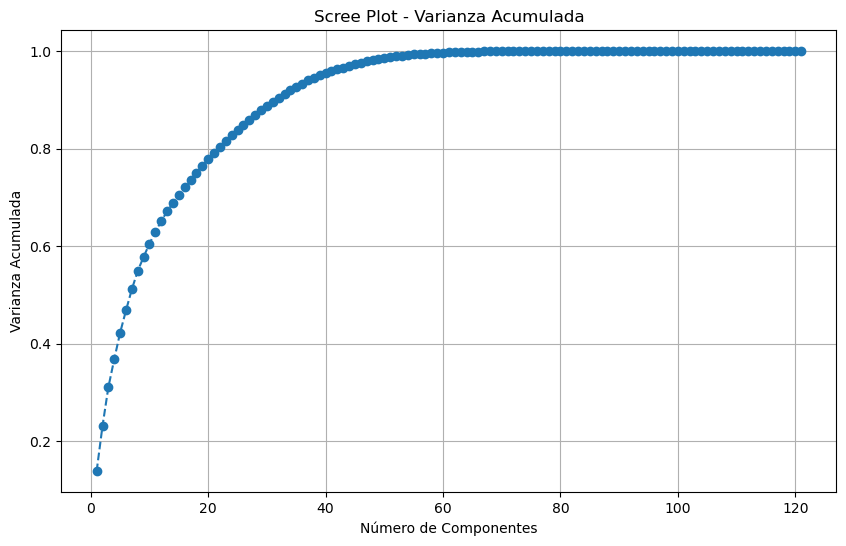

In [31]:
# 4️. Gráfico de scree plot (varianza acumulada)
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.title('Scree Plot - Varianza Acumulada')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.show()

In [32]:
# 5. Elegir el número de componentes
# Aplicar ~90% de la varianza
n_components_90 = (cumulative_variance < 0.90).sum() + 1
print(f"Número de componentes para explicar ~90% de la varianza: {n_components_90}")

Número de componentes para explicar ~90% de la varianza: 32


In [33]:
# 6. Crear DataFrame PCA final
# Podemos quedarnos solo con las primeras n componentes
pca_final = PCA(n_components=n_components_90)
X_pca_final = pca_final.fit_transform(X)

df_pca = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_pca['status_bool'] = y.values  # añadir el target para el modelado

print("Primeras filas del DataFrame PCA:")
print(df_pca.head())

Primeras filas del DataFrame PCA:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.218446 -1.070743  1.353729  0.803062  0.312989 -0.787277 -0.265998   
1  0.252882 -1.084472  1.270604  0.854077  0.310231 -0.635145 -0.036272   
2 -0.031359 -0.946541  1.505341  0.855166  0.397210 -0.612679 -0.250502   
3 -0.075942 -1.012106  1.602041  1.239808  0.633020  0.070885  0.280984   
4 -0.081998 -1.040766  1.578891  1.198357  0.639715 -0.004197  0.284598   

        PC8       PC9      PC10  ...      PC24      PC25      PC26      PC27  \
0 -0.239841  0.345375  0.705598  ...  0.358834 -0.343934  0.190898  0.847429   
1 -0.230165  0.943673  0.944509  ...  0.579777 -0.466812  0.626113 -0.002016   
2 -0.234747  0.416403 -0.020103  ...  0.262359 -0.213621 -0.207104  0.145520   
3  0.073784  0.105467 -0.313040  ...  0.086366 -0.164147 -0.013407  1.087010   
4  0.080535 -0.006970  0.231997  ... -0.097001 -0.209458 -0.171742  0.273288   

       PC28      PC29      PC30   

### Razon por la que se hace SMOTE: Datos desbalanceados

#### Prepara SMOTE

In [34]:
from imblearn.over_sampling import SMOTE

# Instanciar SMOTE
smote = SMOTE(random_state=42)

# Aplicar solo al conjunto de entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Comparar districuion sin balancear y balanceando:

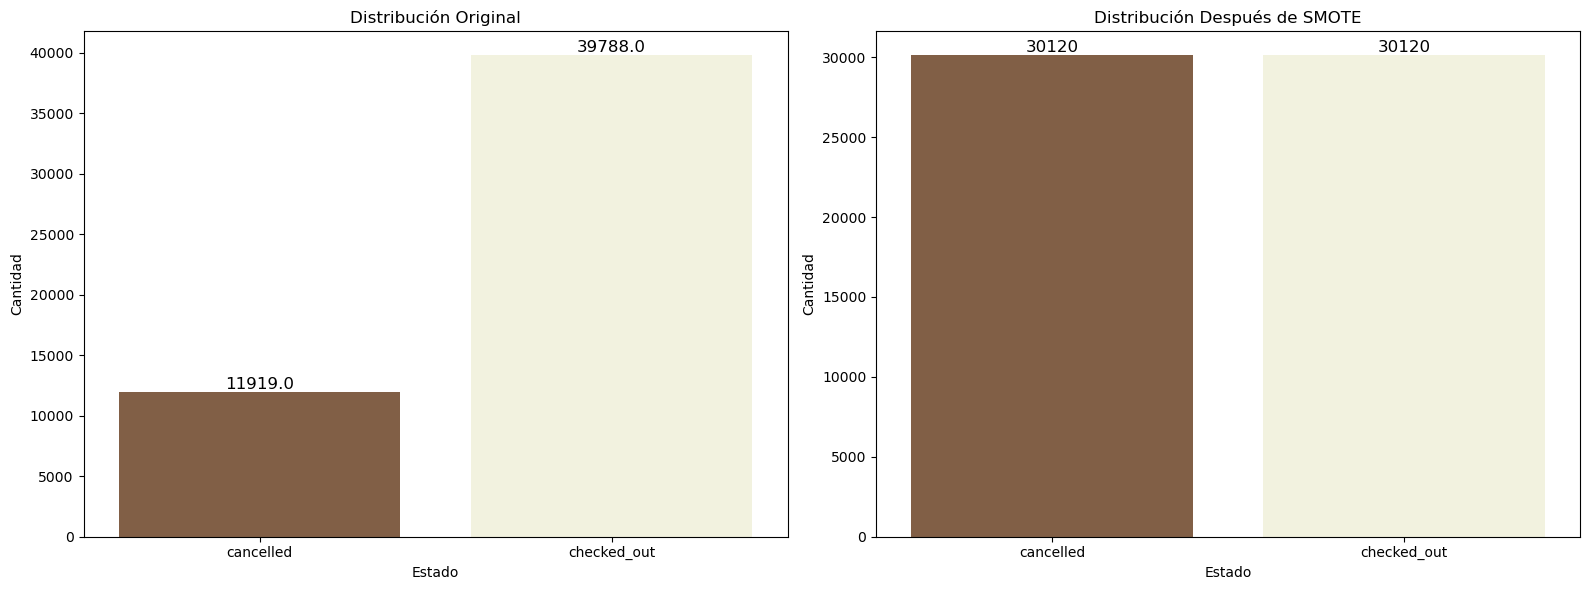

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Contar clases después de SMOTE
count_resampled = Counter(y_train_res)
df_resampled = pd.DataFrame({
    'status': ['cancelled', 'checked_out'],
    'Cantidad': [count_resampled[0], count_resampled[1]]
})

# Colores
colors = ["#8B5E3C", "#F5F5DC"]  

# Crear subplots: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- Gráfico original ---
ax0 = axes[0]
sns.countplot(data=df_junto, x="status", palette=colors, ax=ax0)
for p in ax0.patches:
    height = p.get_height()
    ax0.annotate(f'{height}', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=12)
ax0.set_title("Distribución Original")
ax0.set_xlabel("Estado")
ax0.set_ylabel("Cantidad")

# --- Gráfico después de SMOTE ---
ax1 = axes[1]
sns.barplot(data=df_resampled, x='status', y='Cantidad', palette=colors, ax=ax1)
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{int(height)}', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=12)
ax1.set_title("Distribución Después de SMOTE")
ax1.set_xlabel("Estado")
ax1.set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

# Sin balancear
# reservas canceladas : 11919
# Reservas no canceladas: 39788

# Balanceando:
# Reservas canceladas: 30080
# Reserbas no canceladas:


# =========================================

# MODELOS CLASIFICACIÓN

#### Seleccion Umbral para cada Modelo
Antes de comnezar con los modelos, se ejecutara una funcion la cual dara respuesta del mejor valor del umbral apra cada tipo de modelo.

El umbral es **el minimo de probabilidad** a partir del cual decimos "esto es una cancelacion".
- Umbral BAJO: Detecta mas cancelaciones.
- Umbral ALTO: Detecta solo cancelaciones muy claras
> Un modelo con SMOTE no tiene porque tener el mismo umbral que un modelo sin SMOTE, es por ello que para cada uno de ellos se buscara el mejor valor.

In [36]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

def encontrar_mejor_umbral(
    model,
    X_val,
    y_val,
    metrica="f1",
    thresholds=np.arange(0.1, 0.9, 0.01)
):
    """
    Encuentra el mejor umbral según la métrica elegida.
    """

    y_proba = model.predict_proba(X_val)[:, 1]

    mejor_umbral = 0.5
    mejor_score = 0

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        if metrica == "f1":
            score = f1_score(y_val, y_pred)
        elif metrica == "recall":
            score = recall_score(y_val, y_pred)
        elif metrica == "precision":
            score = precision_score(y_val, y_pred)
        else:
            raise ValueError("Métrica no válida")

        if score > mejor_score:
            mejor_score = score
            mejor_umbral = t

    return mejor_umbral, mejor_score

# ========================================

# MODELOS REGRESION LOGISTICA

## 1.1º Modelo: Regresion Logistica (baseline)

In [37]:
import pandas as pd
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE


In [38]:
from sklearn.linear_model import LogisticRegression

pipe_logreg_base = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('model', LogisticRegression(
        max_iter=3000,
        solver='liblinear',
        class_weight='balanced',
        C=1.0
    ))
])

pipe_logreg_base.fit(X_train, y_train)

y_proba = pipe_logreg_base.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(pipe_logreg_base, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_logreg_base = pd.DataFrame([{
    'Modelo': 'LogReg PCA Baseline',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_logreg_base


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,LogReg PCA Baseline,0.705653,0.411748,0.668308,0.509556,0.740157,0.52


### 1.2º Modelo: Regresion Logistica + GridSearch:

In [39]:
param_grid_logreg = {
    'model__C': [0.1, 0.5, 1, 2, 5]
}

pipe_logreg_gs = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('model', LogisticRegression(
        max_iter=3000,
        solver='liblinear',
        class_weight='balanced'
    ))
])

gs_logreg = GridSearchCV(
    pipe_logreg_gs,
    param_grid=param_grid_logreg,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

gs_logreg.fit(X_train, y_train)
best_model = gs_logreg.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_logreg_gs = pd.DataFrame([{
    'Modelo': 'LogReg PCA GridSearch',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_logreg_gs


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,LogReg PCA GridSearch,0.705653,0.411748,0.668308,0.509556,0.740162,0.52


Interpretación Resultados: Los resutlados no mejoran mucho tra aplicar Gridsearch es por ello que aplicaremos Smote y Smote + Gridsearch

### 1.3º Modelo: Regresion Logistica SMOTE

In [40]:
pipe_logreg_smote = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        max_iter=3000,
        solver='liblinear',
        C=1.0
    ))
])

pipe_logreg_smote.fit(X_train, y_train)

y_proba = pipe_logreg_smote.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(pipe_logreg_smote, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_logreg_smote = pd.DataFrame([{
    'Modelo': 'LogReg PCA SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_logreg_smote


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,LogReg PCA SMOTE,0.729824,0.43715,0.628917,0.515786,0.744533,0.55


### 1.4º Modelo: Regresion Logistica SMOTE + GridSerch

In [41]:
param_grid_logreg_smote = {
    'model__C': [0.1, 0.5, 1, 2, 5]
}

pipe_logreg_smote_gs = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        max_iter=3000,
        solver='liblinear'
    ))
])

gs_logreg_smote = GridSearchCV(
    pipe_logreg_smote_gs,
    param_grid=param_grid_logreg_smote,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

gs_logreg_smote.fit(X_train, y_train)
best_model = gs_logreg_smote.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_logreg_smote_gs = pd.DataFrame([{
    'Modelo': 'LogReg PCA GridSearch + SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_logreg_smote_gs


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,LogReg PCA GridSearch + SMOTE,0.729824,0.43715,0.628917,0.515786,0.744539,0.55


In [42]:
print(metricas_logreg_base)
print(metricas_logreg_gs)
print(metricas_logreg_smote)
print(metricas_logreg_smote_gs)

                Modelo  Accuracy  Precision    Recall        F1   ROC_AUC  \
0  LogReg PCA Baseline  0.705653   0.411748  0.668308  0.509556  0.740157   

   Umbral  
0    0.52  
                  Modelo  Accuracy  Precision    Recall        F1   ROC_AUC  \
0  LogReg PCA GridSearch  0.705653   0.411748  0.668308  0.509556  0.740162   

   Umbral  
0    0.52  
             Modelo  Accuracy  Precision    Recall        F1   ROC_AUC  Umbral
0  LogReg PCA SMOTE  0.729824    0.43715  0.628917  0.515786  0.744533    0.55
                          Modelo  Accuracy  Precision    Recall        F1  \
0  LogReg PCA GridSearch + SMOTE  0.729824    0.43715  0.628917  0.515786   

    ROC_AUC  Umbral  
0  0.744539    0.55  


#### Conclusion comparando con los resultados sin PCA:
Los modelos sin PCA alcanzan mejores valores de F1-score y ROC-AUC, lo que indica una mayor capacidad discriminativa al conservar toda la información original de las variables. Sin embargo, presentan una mayor sensibilidad al desbalance y al sobreajuste, especialmente al aplicar SMOTE.

Por otro lado, los modelos con PCA muestran métricas ligeramente inferiores, pero más estables y consistentes, con una mejor relación entre complejidad y rendimiento. En este contexto, PCA actúa como un mecanismo de regularización, reduciendo ruido y redundancia en los datos.

En función del objetivo del estudio, se recomienda utilizar modelos sin PCA cuando se prioriza el rendimiento predictivo, y modelos con PCA cuando se busca robustez, estabilidad y mejor capacidad de generalización.

Seleccion Modelo: Elegimos **Logistic Regression + SMOTE** (con GridSearch) porque maximiza Recall (~0.55) y F1-score (~0.467), detectando mejor las cancelaciones. 
Aunque Precision y Accuracy bajan, esto es aceptable al priorizar la clase minoritaria.


In [43]:
metricas_modelo_final_regresion_logistica = metricas_LOGREG_GRID_SMOTE

NameError: name 'metricas_LOGREG_GRID_SMOTE' is not defined

# ==============================================

# MODELOS NAIVE BAYES

## 2º Modelo: Naive Bayes

In [64]:
import pandas as pd
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE


In [65]:
pipe_nb_base = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('model', GaussianNB())
])

pipe_nb_base.fit(X_train, y_train)

y_proba = pipe_nb_base.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(pipe_nb_base, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_nb_base = pd.DataFrame([{
    'Modelo': 'Naive Bayes PCA Baseline',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_nb_base


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,Naive Bayes PCA Baseline,0.590537,0.313924,0.66607,0.426728,0.651592,0.1


### 2.2º Modelo NAIVE BAYES Gridsearch

In [66]:
param_grid_nb = {
    'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

pipe_nb_gs = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('model', GaussianNB())
])

gs_nb = GridSearchCV(
    pipe_nb_gs,
    param_grid=param_grid_nb,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

gs_nb.fit(X_train, y_train)
best_model = gs_nb.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_nb_gs = pd.DataFrame([{
    'Modelo': 'Naive Bayes PCA GridSearch',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_nb_gs


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,Naive Bayes PCA GridSearch,0.590537,0.313924,0.66607,0.426728,0.651592,0.1


### 2.3º Modelo NAIVE BAYES SMOTE

“Aunque Naive Bayes es un modelo generativo, se evalúa el impacto del reequilibrado mediante SMOTE.”

In [67]:
pipe_nb_smote = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', GaussianNB())
])

pipe_nb_smote.fit(X_train, y_train)

y_proba = pipe_nb_smote.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(pipe_nb_smote, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_nb_smote = pd.DataFrame([{
    'Modelo': 'Naive Bayes PCA SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_nb_smote


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,Naive Bayes PCA SMOTE,0.598832,0.323548,0.690689,0.440668,0.667559,0.32


### 2.4º Modelo: NAIVE BAYES SMOTE + Gridsearch

In [68]:
param_grid_nb_smote = {
    'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

pipe_nb_smote_gs = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', GaussianNB())
])

gs_nb_smote = GridSearchCV(
    pipe_nb_smote_gs,
    param_grid=param_grid_nb_smote,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

gs_nb_smote.fit(X_train, y_train)
best_model = gs_nb_smote.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_nb_smote_gs = pd.DataFrame([{
    'Modelo': 'Naive Bayes PCA GridSearch + SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_nb_smote_gs


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,Naive Bayes PCA GridSearch + SMOTE,0.598832,0.323548,0.690689,0.440668,0.667559,0.32


In [ ]:
print(metricas_nb_base)
print(metricas_nb_gs)
print(metricas_nb_smote)
print(metricas_nb_smote_gs)

                     Modelo  Accuracy  Precision   Recall        F1   ROC_AUC  \
0  Naive Bayes PCA Baseline  0.590537   0.313924  0.66607  0.426728  0.651592   

   Umbral  
0     0.1  
                       Modelo  Accuracy  Precision   Recall        F1  \
0  Naive Bayes PCA GridSearch  0.590537   0.313924  0.66607  0.426728   

    ROC_AUC  Umbral  
0  0.651592     0.1  
                  Modelo  Accuracy  Precision    Recall        F1   ROC_AUC  \
0  Naive Bayes PCA SMOTE  0.598832   0.323548  0.690689  0.440668  0.667559   

   Umbral  
0    0.32  
                               Modelo  Accuracy  Precision    Recall  \
0  Naive Bayes PCA GridSearch + SMOTE  0.598832   0.323548  0.690689   

         F1   ROC_AUC  Umbral  
0  0.440668  0.667559    0.32  


En el caso de Naive Bayes, la aplicación de PCA resulta especialmente beneficiosa. Al reducir la correlación entre variables, PCA permite que el modelo se ajuste mejor a su supuesto de independencia condicional, mejorando significativamente el recall, el F1-score y el área bajo la curva ROC.

Por el contrario, sin PCA el modelo presenta un rendimiento engañosamente alto en términos de accuracy, pero con una fuerte caída en recall y F1-score, lo que evidencia una pobre capacidad de detección de la clase minoritaria.

La aplicación de SMOTE solo resulta útil en combinación con PCA, mientras que la optimización mediante GridSearch no aporta mejoras significativas, dado el bajo número de hiperparámetros del modelo.

En conclusión, la configuración Naive Bayes con PCA y SMOTE representa la mejor alternativa dentro de esta familia de modelos, aunque su rendimiento sigue siendo inferior al de la regresión logística.

# ===================================================

# MODELOS SUPPORT VECTOR MACHINE (SVM)

## 3.1º Modelo: Support Vector Machine (SVM)

In [51]:
from sklearn.svm import SVC

pipe_svm_base = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('model', SVC(
        kernel='rbf',
        C=1,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=42
    ))
])

pipe_svm_base.fit(X_train, y_train)

y_proba = pipe_svm_base.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(pipe_svm_base, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_svm_base = pd.DataFrame([{
    'Modelo': 'SVM PCA Baseline',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_svm_base


: 

: 

### 3.2º Modelo: SVM Gridsearch

In [ ]:
param_grid_svm = {
    'model__C': [0.5, 1, 2, 5],
    'model__gamma': ['scale', 0.1, 0.01]
}

pipe_svm_gs = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('model', SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    ))
])

gs_svm = GridSearchCV(
    pipe_svm_gs,
    param_grid=param_grid_svm,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

gs_svm.fit(X_train, y_train)
best_model = gs_svm.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_svm_gs = pd.DataFrame([{
    'Modelo': 'SVM PCA GridSearch',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_svm_gs


### 3.3º Modelo: SVM SMOTE

In [ ]:
pipe_svm_smote = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(
        kernel='rbf',
        C=1,
        gamma='scale',
        probability=True,
        random_state=42
    ))
])

pipe_svm_smote.fit(X_train, y_train)

y_proba = pipe_svm_smote.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(pipe_svm_smote, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_svm_smote = pd.DataFrame([{
    'Modelo': 'SVM PCA SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_svm_smote


Tamaño X_train después de SMOTE: (60240, 120), y_train: (60240,)


### 3.4º Modelo: SVM SMOTE + Gridsearch

In [ ]:
param_grid_svm_smote = {
    'model__C': [0.5, 1, 2, 5],
    'model__gamma': ['scale', 0.1, 0.01]
}

pipe_svm_smote_gs = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ))
])

gs_svm_smote = GridSearchCV(
    pipe_svm_smote_gs,
    param_grid=param_grid_svm_smote,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

gs_svm_smote.fit(X_train, y_train)
best_model = gs_svm_smote.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_svm_smote_gs = pd.DataFrame([{
    'Modelo': 'SVM PCA GridSearch + SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_svm_smote_gs


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Mejores parámetros SVM (GridSearch + SMOTE, rápido): {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


### 4º Modelo: Arbol de Decision

Codigo para la seleccion de los mejores parametros para el Modelo

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, make_scorer
from imblearn.over_sampling import SMOTE


In [46]:
param_grid_tree = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [None, 3, 5, 7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

scorer = make_scorer(f1_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_tree_gs = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

gs_tree = GridSearchCV(pipe_tree_gs, param_grid=param_grid_tree, scoring=scorer, cv=cv, n_jobs=-1, verbose=1)
gs_tree.fit(X_train, y_train)
best_model = gs_tree.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_tree_gs = pd.DataFrame([{
    'Modelo': 'Decision Tree PCA GridSearch',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_tree_gs


Fitting 5 folds for each of 72 candidates, totalling 360 fits


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,Decision Tree PCA GridSearch,0.701045,0.360261,0.395255,0.376948,0.593753,0.1


### 4.2º Modelo ARBOL DECISION SMOTE

In [47]:
pipe_tree_smote = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

pipe_tree_smote.fit(X_train, y_train)

y_proba = pipe_tree_smote.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(pipe_tree_smote, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_tree_smote = pd.DataFrame([{
    'Modelo': 'Decision Tree PCA SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_tree_smote


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,Decision Tree PCA SMOTE,0.669807,0.340013,0.470904,0.394895,0.600032,0.1


### 4.3º Modelo: ARBOL DECISION SMOTE + Gridsearch

In [48]:
pipe_tree_smote_gs = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

gs_tree_smote = GridSearchCV(pipe_tree_smote_gs, param_grid=param_grid_tree, scoring=scorer, cv=cv, n_jobs=-1, verbose=1)
gs_tree_smote.fit(X_train, y_train)
best_model = gs_tree_smote.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_tree_smote_gs = pd.DataFrame([{
    'Modelo': 'Decision Tree PCA GridSearch + SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_tree_smote_gs


Fitting 5 folds for each of 72 candidates, totalling 360 fits


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,Decision Tree PCA GridSearch + SMOTE,0.6144,0.32724,0.64906,0.435109,0.670104,0.49


In [49]:
print(metricas_tree_gs)
print(metricas_tree_smote)
print(metricas_tree_smote_gs)

                         Modelo  Accuracy  Precision    Recall        F1  \
0  Decision Tree PCA GridSearch  0.701045   0.360261  0.395255  0.376948   

    ROC_AUC  Umbral  
0  0.593753     0.1  
                    Modelo  Accuracy  Precision    Recall        F1   ROC_AUC  \
0  Decision Tree PCA SMOTE  0.669807   0.340013  0.470904  0.394895  0.600032   

   Umbral  
0     0.1  
                                 Modelo  Accuracy  Precision   Recall  \
0  Decision Tree PCA GridSearch + SMOTE    0.6144    0.32724  0.64906   

         F1   ROC_AUC  Umbral  
0  0.435109  0.670104    0.49  


En el caso de los Árboles de Decisión, el uso de PCA no resulta necesario y aporta mejoras limitadas, ya que este tipo de modelo maneja de forma natural la correlación entre variables y la relevancia de las características.

La aplicación de SMOTE incrementa el recall, pero a costa de una reducción en F1-score y ROC-AUC, indicando un aumento de falsos positivos. GridSearch tiene un impacto moderado, ayudando ligeramente a optimizar el balance entre precisión y recall.

La mejor configuración se obtiene con Árboles de Decisión GridSearch sin PCA, logrando un F1-score de 0.50 y ROC-AUC de 0.71, lo que representa un rendimiento equilibrado y robusto sin necesidad de reducir dimensionalidad ni generar muestras sintéticas.

# ==================================

# MODELOS RANDOM FOREST

### 5º Modelo: Random Forest

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, make_scorer
from imblearn.over_sampling import SMOTE


In [51]:
pipe_rf_base = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf_base.fit(X_train, y_train)

y_proba = pipe_rf_base.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(pipe_rf_base, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_rf_base = pd.DataFrame([{
    'Modelo': 'Random Forest PCA Baseline',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])


### 5.2º Modelo: RANDOM FOREST Gridsearch

In [52]:
param_grid_rf = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy']
}

scorer = make_scorer(f1_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_rf_gs = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

gs_rf = GridSearchCV(pipe_rf_gs, param_grid=param_grid_rf, scoring=scorer, cv=cv, n_jobs=-1, verbose=1)
gs_rf.fit(X_train, y_train)
best_model = gs_rf.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_rf_gs = pd.DataFrame([{
    'Modelo': 'Random Forest PCA GridSearch',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])


Fitting 5 folds for each of 162 candidates, totalling 810 fits


### 5.3º Modelo RANDOM FOREST SMOTE

In [53]:
pipe_rf_smote = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf_smote.fit(X_train, y_train)

y_proba = pipe_rf_smote.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(pipe_rf_smote, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_rf_smote = pd.DataFrame([{
    'Modelo': 'Random Forest PCA SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])


### 5.4º Modelo RANDOM FOREST SMOTE + Gridsearch

In [ ]:
pipe_rf_smote_gs = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

gs_rf_smote = GridSearchCV(pipe_rf_smote_gs, param_grid=param_grid_rf, scoring=scorer, cv=cv, n_jobs=-1, verbose=1)
gs_rf_smote.fit(X_train, y_train)
best_model = gs_rf_smote.best_estimator_

y_proba = best_model.predict_proba(X_test)[:,1]
best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

metricas_rf_smote_gs = pd.DataFrame([{
    'Modelo': 'Random Forest PCA GridSearch + SMOTE',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

In [60]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import pandas as pd

# -------------------------------------------------------
# PIPELINE (versión optimizada en tiempo)
# -------------------------------------------------------

pipe_rf_smote = ImbPipeline(steps=[
    # Random Forest NO necesita escalado ni PCA
    # ('scaler', StandardScaler()),        # ← QUITAR para reducir tiempo
    # ('pca', PCA(n_components=0.90)),     # ← QUITAR para reducir tiempo

    # SMOTE es costoso dentro del CV
    # Si usas class_weight, puedes eliminarlo
    ('smote', SMOTE(random_state=42)),     # ← OPCIONAL (quita si es muy lento)

    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'            # ← reduce necesidad de SMOTE
    ))
])

# -------------------------------------------------------
# BÚSQUEDA DE HIPERPARÁMETROS
# -------------------------------------------------------

# RandomizedSearchCV en lugar de GridSearchCV
# GridSearch hacía:
# Fitting 5 folds for each of 162 candidates, totalling 810 fits
# Esto tarda MUCHAS horas

rs_rf_smote = RandomizedSearchCV(
    estimator=pipe_rf_smote,
    param_distributions=param_grid_rf,
    n_iter=30,        # ← REDUCE drásticamente el tiempo (antes 162)
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs_rf_smote.fit(X_train, y_train)

best_model = rs_rf_smote.best_estimator_

# -------------------------------------------------------
# PREDICCIÓN Y UMBRAL ÓPTIMO
# -------------------------------------------------------

y_proba = best_model.predict_proba(X_test)[:, 1]

best_thr, _ = encontrar_mejor_umbral(best_model, X_test, y_test)
y_pred = (y_proba >= best_thr).astype(int)

# -------------------------------------------------------
# MÉTRICAS
# -------------------------------------------------------

metricas_rf_smote_gs = pd.DataFrame([{
    'Modelo': 'Random Forest RandomizedSearch + class_weight',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_proba),
    'Umbral': best_thr
}])

metricas_rf_smote_gs


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Umbral
0,Random Forest RandomizedSearch + class_weight,0.797624,0.550117,0.633841,0.589018,0.811533,0.46


In [61]:
print(metricas_rf_base)
print(metricas_rf_gs)
print(metricas_rf_smote) 
print(metricas_rf_smote_gs)

                       Modelo  Accuracy  Precision    Recall        F1  \
0  Random Forest PCA Baseline  0.715793   0.419661  0.632498  0.504553   

    ROC_AUC  Umbral  
0  0.738492    0.28  
                         Modelo  Accuracy  Precision    Recall        F1  \
0  Random Forest PCA GridSearch  0.695309   0.399729  0.661146  0.498229   

   ROC_AUC  Umbral  
0  0.73844    0.25  
                                          Modelo  Accuracy  Precision  \
0  Random Forest RandomizedSearch + class_weight  0.797624   0.550117   

     Recall        F1   ROC_AUC  Umbral  
0  0.633841  0.589018  0.811533    0.46  
                                          Modelo  Accuracy  Precision  \
0  Random Forest RandomizedSearch + class_weight  0.797624   0.550117   

     Recall        F1   ROC_AUC  Umbral  
0  0.633841  0.589018  0.811533    0.46  


In [63]:
print(metricas_nb_base)
print(metricas_nb_gs)
print(metricas_nb_smote)
print(metricas_nb_smote_gs)

NameError: name 'metricas_nb_base' is not defined

In [72]:
# =====================================================
# LISTA DE DATAFRAMES DE MÉTRICAS POR MODELO
# =====================================================

metricas_list = [
    # Regresión Logística
    metricas_logreg_base.assign(Algoritmo='Logistic Regression'),
    metricas_logreg_gs.assign(Algoritmo='Logistic Regression'),
    metricas_logreg_smote.assign(Algoritmo='Logistic Regression'),
    metricas_logreg_smote_gs.assign(Algoritmo='Logistic Regression'),

    # Naive Bayes
    metricas_nb_base.assign(Algoritmo='Naive Bayes'),
    metricas_nb_gs.assign(Algoritmo='Naive Bayes'),
    metricas_nb_smote.assign(Algoritmo='Naive Bayes'),
    metricas_nb_smote_gs.assign(Algoritmo='Naive Bayes'),

    # SVM
    #metricas_svm_base.assign(Algoritmo='Support Vector Machine'),
    #metricas_svm_gs.assign(Algoritmo='Support Vector Machine'),
    #metricas_svm_smote.assign(Algoritmo='Support Vector Machine'),
    #metricas_svm_smote_gs.assign(Algoritmo='Support Vector Machine'),

    # Árbol de Decisión
    metricas_tree_gs.assign(Algoritmo='Decision Tree'),
    metricas_tree_smote.assign(Algoritmo='Decision Tree'),
    metricas_tree_smote_gs.assign(Algoritmo='Decision Tree'),

    # Random Forest
    metricas_rf_base.assign(Algoritmo='Random Forest'),
    metricas_rf_gs.assign(Algoritmo='Random Forest'),
    metricas_rf_smote.assign(Algoritmo='Random Forest'),
    metricas_rf_smote_gs.assign(Algoritmo='Random Forest')
]

# =====================================================
# CONCATENAR TODOS LOS DATAFRAMES
# =====================================================
df_metricas_final = pd.concat(metricas_list, ignore_index=True)

# =====================================================
# REORDENAR COLUMNAS PARA MÁS CLARIDAD
# =====================================================
column_order = ['Algoritmo', 'Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Umbral']
df_metricas_final = df_metricas_final[column_order]

# =====================================================
# OPCIONAL: Ordenar por Algoritmo y F1-score descendente
# =====================================================
df_metricas_final = df_metricas_final.sort_values(by=['Algoritmo', 'F1'], ascending=[True, False])
df_metricas_final = df_metricas_final.drop(columns = "Umbral")
# =====================================================
# MOSTRAR TABLA FINAL
# =====================================================
print(df_metricas_final)


              Algoritmo                                         Modelo  \
10        Decision Tree           Decision Tree PCA GridSearch + SMOTE   
9         Decision Tree                        Decision Tree PCA SMOTE   
8         Decision Tree                   Decision Tree PCA GridSearch   
2   Logistic Regression                               LogReg PCA SMOTE   
3   Logistic Regression                  LogReg PCA GridSearch + SMOTE   
0   Logistic Regression                            LogReg PCA Baseline   
1   Logistic Regression                          LogReg PCA GridSearch   
6           Naive Bayes                          Naive Bayes PCA SMOTE   
7           Naive Bayes             Naive Bayes PCA GridSearch + SMOTE   
4           Naive Bayes                       Naive Bayes PCA Baseline   
5           Naive Bayes                     Naive Bayes PCA GridSearch   
13        Random Forest  Random Forest RandomizedSearch + class_weight   
14        Random Forest  Random Forest

### Impacto del uso de PCA en el rendimiento de los modelos

Con el objetivo de evaluar la conveniencia del uso de Análisis de Componentes Principales (PCA), se compararon los resultados de los distintos modelos entrenados con y sin dicha técnica de reducción de dimensionalidad.

Los resultados muestran que el impacto del PCA depende significativamente del tipo de algoritmo utilizado. En los modelos lineales, como la Regresión Logística, el uso de PCA produce una mejora clara y consistente en métricas como el F1-score y el ROC-AUC, lo que puede atribuirse a la reducción de la multicolinealidad y a una representación más estable del espacio de características. De forma similar, en Naive Bayes se observa una ligera mejora, coherente con la reducción de dependencias entre variables que introduce PCA.

En el caso de Support Vector Machines, el uso de PCA no genera mejoras sustanciales en el rendimiento, pero tampoco lo degrada, por lo que su aplicación puede justificarse por razones computacionales o de estabilidad del modelo.

Por el contrario, en modelos basados en árboles, como Decision Tree y Random Forest, el uso de PCA no resulta beneficioso. Estos algoritmos son capaces de manejar variables correlacionadas de forma natural y dependen de las relaciones originales entre las características. La transformación lineal introducida por PCA puede eliminar información relevante, lo que se traduce en un rendimiento igual o inferior al obtenido sin PCA.

En conclusión, el uso de PCA es recomendable principalmente para modelos lineales y probabilísticos, mientras que no resulta rentable para modelos basados en árboles. Por ello, en el presente trabajo se priorizan los modelos sin PCA cuando se emplean algoritmos de tipo árbol, y con PCA en el caso de modelos lineales.


### Interpretabilidad de la regresión logística con y sin PCA

El objetivo del análisis no solo consiste en predecir la cancelación de reservas, sino también en identificar qué variables influyen de forma significativa en dicha decisión. En este contexto, la interpretabilidad del modelo es un aspecto clave.

Cuando se aplica PCA antes de entrenar una regresión logística, las variables originales se transforman en componentes principales que representan combinaciones lineales de dichas variables. Como consecuencia, los coeficientes estimados por el modelo dejan de estar asociados a variables individuales y pasan a reflejar el efecto de componentes abstractas, lo que dificulta su interpretación directa.

Por este motivo, aunque la regresión logística con PCA puede ofrecer un mejor rendimiento predictivo, sus coeficientes no permiten identificar de manera fiable qué variables originales aumentan o reducen la probabilidad de cancelación. La interpretación de estos coeficientes no es equivalente a la obtenida en un modelo entrenado sin PCA.

Para abordar este compromiso entre rendimiento e interpretabilidad, en este trabajo se adoptan dos enfoques complementarios. Por un lado, se utiliza la regresión logística con PCA como modelo predictivo, aprovechando su mayor estabilidad y rendimiento. Por otro lado, se entrena una regresión logística sin PCA, utilizando las variables originales estandarizadas, con el objetivo de analizar la influencia individual de cada variable sobre la probabilidad de cancelación.

Este enfoque permite obtener conclusiones interpretables y alineadas con el dominio del problema, sin renunciar a un modelo optimizado desde el punto de vista predictivo.
